# 09 – Pivot Analysis

Ce notebook charge les artefacts `probabilities` générés par un run MLflow (cf. `08_modeling_point_total.ipynb`) et visualise la calibration des probabilités over/under pour chaque pivot. Ajuste les chemins ci-dessous pour pointer vers le run/ modèle que tu veux analyser.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from src.mlflow_utils import get_latest_run_dir

RUN_DIR = get_latest_run_dir(target="POINT_TOTAL", experiment_name="point_total_regression")


MODEL_KEY = "ngboost"  # 'lgbm', 'xgb', 'ngboost', 'stacking'

summary_path = RUN_DIR / "artifacts" / "probabilities" / MODEL_KEY / f"{MODEL_KEY}_pivot_summary.csv"
samples_path = RUN_DIR / "artifacts" / "probabilities" / MODEL_KEY / "samples" / f"{MODEL_KEY}_pivot_samples.csv"

summary_df = pd.read_csv(summary_path)
samples_df = pd.read_csv(samples_path)
samples_df["actual_over"] = (samples_df["actual"] > samples_df["pivot"]).astype(int)
samples_df["pred_over"] = samples_df["prob_over"]

display(summary_df.head())
display(samples_df.head())

,pivot,prob_under,prob_over
0,218.5,0.745250,0.254750
1,219.5,0.760143,0.239857
2,220.5,0.774548,0.225452
3,221.5,0.788451,0.211549
4,222.5,0.801841,0.198159


,prediction,actual,sigma,pivot,prob_under,prob_over,actual_over,pred_over
0,215.923572,210,16.904311,243.5,0.948589,0.051411,0,0.051411
1,217.083815,237,19.111249,227.5,0.707133,0.292867,1,0.292867
2,205.066788,167,15.460930,239.5,0.987030,0.012970,0,0.012970
3,214.547263,194,17.280099,220.5,0.634759,0.365241,0,0.365241
4,193.613313,213,13.466487,227.5,0.994071,0.005929,0,0.005929


## Calibration par pivot

,pivot,actual_over_rate,predicted_over,count
0,218.5,0.325000,0.272600,40
1,219.5,0.285714,0.237673,42
2,220.5,0.258065,0.205301,31
3,221.5,0.250000,0.235184,24
4,222.5,0.250000,0.224633,36
5,223.5,0.218750,0.189848,32
6,224.5,0.160000,0.162981,50
7,225.5,0.146341,0.122551,41
8,226.5,0.114286,0.167536,35
9,227.5,0.205882,0.123109,34


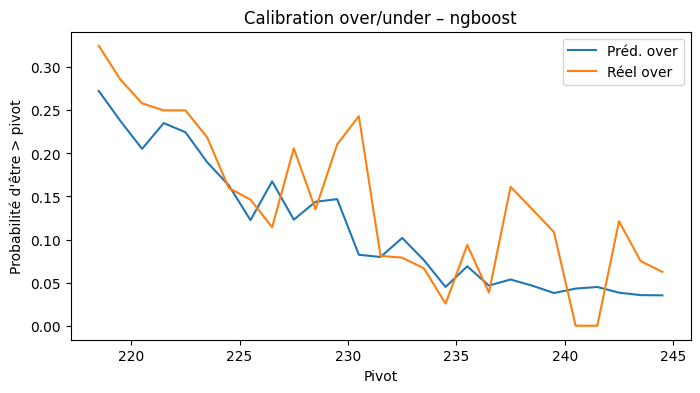

In [2]:
pivot_stats = (
    samples_df.groupby("pivot")
    .agg(
        actual_over_rate=("actual_over", "mean"),
        predicted_over=("pred_over", "mean"),
        count=("actual_over", "size"),
    )
    .reset_index()
)

display(pivot_stats)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(pivot_stats["pivot"], pivot_stats["predicted_over"], label="Préd. over")
ax.plot(pivot_stats["pivot"], pivot_stats["actual_over_rate"], label="Réel over")
ax.set_xlabel("Pivot")
ax.set_ylabel("Probabilité d'être > pivot")
ax.legend()
ax.set_title(f"Calibration over/under – {MODEL_KEY}")
plt.show()

## Classement des pivots les plus "sûrs"

On calcule ci-dessous un score simple : distance entre la probabilité de dépassement et 0.5 (plus la probabilité est éloignée de 50 %, plus le modèle est confiant), pondéré par la différence entre la prédiction et la réalité.

In [3]:
samples_df["confidence"] = (samples_df["prob_over"] - 0.5).abs()
samples_df["hit"] = (samples_df["prob_over"] > 0.5) == (samples_df["actual"] > samples_df["pivot"])

top_edges = (
    samples_df.sort_values("confidence", ascending=False)
    [["prediction", "actual", "pivot", "prob_over", "prob_under", "confidence", "hit"]]
    .head(20)
)
display(top_edges)

,prediction,actual,pivot,prob_over,prob_under,confidence,hit
856,183.052314,159,231.5,8.663550e-09,1.000000,0.500000,True
653,188.514148,199,244.5,2.876256e-05,0.999971,0.499971,True
265,192.316877,186,242.5,3.619199e-05,0.999964,0.499964,True
262,185.478698,154,241.5,7.596916e-05,0.999924,0.499924,True
621,197.401915,201,241.5,8.271430e-05,0.999917,0.499917,True
833,200.408448,186,243.5,9.878740e-05,0.999901,0.499901,True
850,186.794113,163,239.5,1.013285e-04,0.999899,0.499899,True
271,188.273873,159,243.5,1.300155e-04,0.999870,0.499870,True
802,186.794113,163,238.5,1.336009e-04,0.999866,0.499866,True
505,192.465687,199,243.5,1.701145e-04,0.999830,0.499830,True


## Pivot bins (2 pts)

/tmp/ipykernel_1847396/2097160386.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  samples_df.groupby('pivot_bin')


,pivot_bin,count,actual_over_rate,predicted_over
0,"[218.5, 220.5)",82,0.304878,0.254710
1,"[220.5, 222.5)",55,0.254545,0.218340
2,"[222.5, 224.5)",68,0.235294,0.208264
3,"[224.5, 226.5)",91,0.153846,0.144765
4,"[226.5, 228.5)",69,0.159420,0.145644
5,"[228.5, 230.5)",75,0.173333,0.145420
6,"[230.5, 232.5)",74,0.162162,0.081085
7,"[232.5, 234.5)",83,0.072289,0.087910
8,"[234.5, 236.5)",71,0.056338,0.055797
9,"[236.5, 238.5)",57,0.105263,0.050439


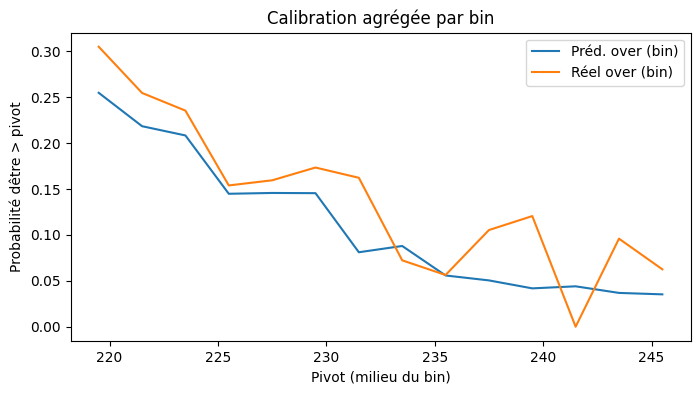

In [4]:
bin_edges = pd.interval_range(start=218.5, end=246.5, freq=2, closed='left')
samples_df['pivot_bin'] = pd.cut(samples_df['pivot'], bins=bin_edges)
bin_stats = (
    samples_df.groupby('pivot_bin')
    .agg(count=('actual_over','size'), actual_over_rate=('actual_over','mean'), predicted_over=('prob_over','mean'))
    .reset_index()
)
display(bin_stats)
if not bin_stats.empty:
    fig, ax = plt.subplots(figsize=(8,4))
    mids = bin_stats['pivot_bin'].apply(lambda x: x.mid if pd.notna(x) else pd.NA)
    ax.plot(mids, bin_stats['predicted_over'], label='Préd. over (bin)')
    ax.plot(mids, bin_stats['actual_over_rate'], label='Réel over (bin)')
    ax.set_xlabel('Pivot (milieu du bin)')
    ax.set_ylabel('Probabilité dêtre > pivot')
    ax.legend()
    ax.set_title('Calibration agrégée par bin')
    plt.show()


## Confiance vs taux de réussite

In [5]:
confidence_thresholds = [0.05, 0.1, 0.15, 0.2, 0.25]
records = []
for thresh in confidence_thresholds:
    subset = samples_df[samples_df['confidence'] >= thresh]
    hit_rate = subset['hit'].mean() if not subset.empty else float('nan')
    records.append({'threshold': thresh, 'count': len(subset), 'hit_rate': hit_rate})
confidence_df = pd.DataFrame(records)
display(confidence_df)


,threshold,count,hit_rate
0,0.05,985,0.867005
1,0.10,966,0.871636
2,0.15,938,0.879531
3,0.20,885,0.892655
4,0.25,825,0.899394


## Distribution des sigma

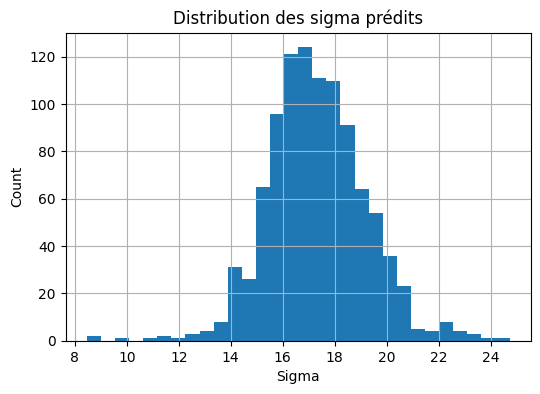

In [6]:
if 'sigma' in samples_df.columns:
    fig, ax = plt.subplots(figsize=(6,4))
    samples_df['sigma'].hist(bins=30, ax=ax)
    ax.set_title('Distribution des sigma prédits')
    ax.set_xlabel('Sigma')
    ax.set_ylabel('Count')
    plt.show()
else:
    print('Colonne sigma absente du fichier samples.')
